In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score
import warnings
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost catboost
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.6 MB/s eta 0:00:00


In [3]:
# Mount Google Drive (to save/load data)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**PROJECT 1: Credit Card Default Prediction**

In [16]:
file_path = '/content/drive/MyDrive/Colab Datasets/UCI_Credit_Card.csv'
df = pd.read_csv(file_path)

In [17]:
print(df.head())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [18]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [19]:
# Define Features and Target
X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

preprocessing

In [22]:
from imblearn.over_sampling import SMOTE

# 1. Normalize Credit Limit (and other continuous features)
scaler = StandardScaler()
X[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']] = scaler.fit_transform(X[['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']])

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Handle Class Imbalance with SMOTE (Synthetic Minority Over-sampling Technique)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original shape: {y_train.value_counts()}")
print(f"Resampled shape: {y_train_res.value_counts()}")

Original shape: default.payment.next.month
0    18677
1     5323
Name: count, dtype: int64
Resampled shape: default.payment.next.month
0    18677
1    18677
Name: count, dtype: int64


model training

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression (Simple baseline)
lr_model = LogisticRegression()
lr_model.fit(X_train_res, y_train_res)

# Random Forest (Ensemble of trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# XGBoost (Gradient Boosting)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

evaluation

In [25]:
models = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'XGBoost': xgb_model}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.2f}")


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.78      4687
           1       0.36      0.58      0.45      1313

    accuracy                           0.68      6000
   macro avg       0.61      0.65      0.61      6000
weighted avg       0.75      0.68      0.71      6000

ROC-AUC Score: 0.69

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4687
           1       0.50      0.48      0.49      1313

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC Score: 0.74

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4687
           1       0.53      0.41      0.46      1313

    accuracy                           0.79      6000
   macro avg       

**2.Customer Churn Prediction (Classification)**

In [26]:
file_path = '/content/drive/MyDrive/Colab Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

In [27]:
# Basic Cleaning: TotalCharges is often read as an object/string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [41]:
# --- Feature Engineering ---
# 1. Customer Lifetime Value (Simplified)
df['CLV'] = df['tenure'] * df['MonthlyCharges']

# 2. Monthly Charge Categories (Binning)
df['ChargeCategory'] = pd.qcut(df['MonthlyCharges'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Drop ID column
df = df.drop(columns=['customerID'], errors='ignore')
print((df))

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0                 1                0

preprocessing

In [29]:
# Encode Categorical Variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Define X and y
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model training

In [42]:
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# 3. CatBoost (Handles categorical structures very well)
cb = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0)
cb.fit(X_train, y_train)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, verbose=0)

evaluation

In [43]:
models = {'Logistic Regression': lr, 'Random Forest': rf, 'CatBoost': cb}

for name, model in models.items():
    # Use scaled data for LR, raw for tree-based models
    data = X_test_scaled if name == 'Logistic Regression' else X_test

    preds = model.predict(data)
    probs = model.predict_proba(data)[:, 1]

    print(f"\n--- {name} ---")
    print(f"F1 Score: {f1_score(y_test, preds):.2f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, probs):.2f}")


--- Logistic Regression ---
F1 Score: 0.62
ROC-AUC: 0.86

--- Random Forest ---
F1 Score: 0.57
ROC-AUC: 0.86

--- CatBoost ---
F1 Score: 0.58
ROC-AUC: 0.86


**3. House Price Prediction (Regression)**

Available columns: Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


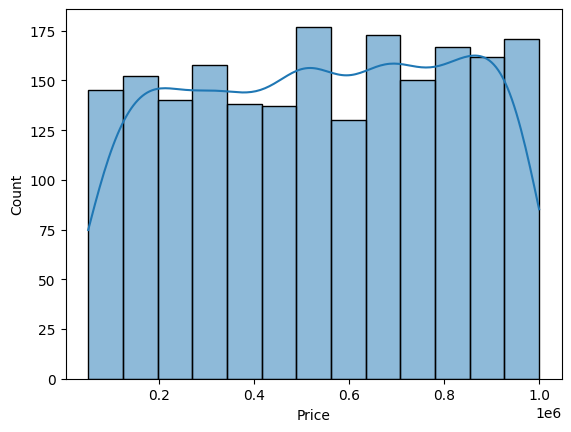

In [51]:
file_path = '/content/drive/MyDrive/Colab Datasets/House Price Prediction Dataset.csv'
df = pd.read_csv(file_path)

# --- Debugging: Print columns to verify ---
print("Available columns:", df.columns)

# --- EDA & Feature Engineering ---
# 1. Visualize target (SalePrice)
sns.histplot(df['Price'], kde=True) # Assuming 'Price' is the correct column name
plt.show()

# 2. Log Transform Target (Fixes skewness)
df['Price'] = np.log1p(df['Price']) # Assuming 'Price' is the correct column name

# 3. Create 'Age' feature
df['HouseAge'] = 2024 - df['YearBuilt']

# Encode 'Garage' column
df['Garage'] = df['Garage'].map({'No': 0, 'Yes': 1}).fillna(0) # Map 'No' to 0, 'Yes' to 1, fill NaNs with 0

# Select key features using available columns
features = ['Area', 'Bedrooms', 'Garage', 'HouseAge']
X = df[features].fillna(0) # Simple fill for missing values
y = df['Price'] # Assuming 'Price' is the correct column name

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training

In [53]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor

# Initialize Models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05)
}

# Train and Predict
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Back-transforming Log to Actual Price for metrics
    actual_preds = np.expm1(preds);
    actual_y_test = np.expm1(y_test);

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(actual_y_test, actual_preds)),
        "MAE": mean_absolute_error(actual_y_test, actual_preds),
        "R2": r2_score(y_test, preds) # R2 calculated on log scale is common
    }

Advanced: Stacking Models

In [54]:
from sklearn.ensemble import StackingRegressor

# Define the base models
estimators = [
    ('ridge', Ridge(alpha=1.0)),
    ('xgb', XGBRegressor(n_estimators=100))
]

# Build Stacked Model
stack_reg = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stack_reg.fit(X_train, y_train)

stack_preds = np.expm1(stack_reg.predict(X_test))
print(f"Stacked RMSE: {np.sqrt(mean_squared_error(np.expm1(y_test), stack_preds))}")

Stacked RMSE: 296841.70765381784
